# Proyecto 8 - Explorando factores de comportamiento en NovaRetail+


## Sección 1 - Cargar y explorar el dataset

In [1]:
# Importar librerías
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.
La columna `edad` puede manejarse como `int64` dada la naturaleza de los datos.

**Variables binarias**
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['edad']=df['edad'].astype("int")

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas = df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']]
columnas_numericas.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


Diagnóstico inicial de variables numéricas

- `edad` — Columna con valores correctos, no hay presencia de valores sentine. Datos con distribución probablemente normal (media y mediana similar).
- `nivel_ingreso` — Valores completos, presentan una elevada desviación estandar, sin embargo, la media y la mediana se mantienen similar.
- `visitas_mes` — No se detectan outliers a primera instancia.
- `compras_mes` —  No se detectan outliers a primera instancia (tomar en cuenta los valores igual a 0 para futura segmentación).
- `gasto_publicidad_dirigida` — No se detectan outliers a primera instancia (considerar valores igual a 0 para futuors análisis).
- `satisfacción` presenta baja variabilidad (std: 0.68)
- `ingreso_anual` presenta alta variabilidad (mean: 36.59 | std: 34.48)

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("Valores únicos en `miembro_premium`:", df['miembro_premium'].unique())
print("\nValores únicos en `abandono`:", df['abandono'].unique())

Valores únicos en `miembro_premium`: [0 1]

Valores únicos en `abandono`: [0 1]


Diagnóstico inicial de variables binarias

- `miembro_premium` — Valores adecuados para variables binarias
- `abandono` —  Valores adecuados para variables binarias

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
print("Valores únicos en `id_cliente`:", df['id_cliente'].nunique())
print("\nValores únicos en `tipo_dispositivo`:", df['tipo_dispositivo'].unique())
print("\nValores únicos en `region`:", df['region'].unique())

Valores únicos en `id_cliente`: 15000

Valores únicos en `tipo_dispositivo`: ['móvil' 'tablet' 'escritorio']

Valores únicos en `region`: ['norte' 'sur' 'este' 'oeste']


In [9]:
# Explorar variables categóricas y cómo se distribuyen
print( "**Distribución del tipo de dispositivo:**" )
print( df['tipo_dispositivo'].value_counts() )
print( "\n**Distribución de la región:**" )
print( df['region'].value_counts() )
print( "\n**Distribución de usuarios por tipo de dispositivo y región:**")
print( df.groupby(df['tipo_dispositivo'])['region'].value_counts() )

**Distribución del tipo de dispositivo:**
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

**Distribución de la región:**
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

**Distribución de usuarios por tipo de dispositivo y región:**
tipo_dispositivo  region
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
Name: region, dtype: int64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — La mayor cantidad de usuarios utilizan móvil para interactuar con el negocio.
- `region` — La región norte contiene la mayor cantidad de usuarios

Se integró la distribución de usuarios por tipo de dispositivo y región.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

### Heatmap

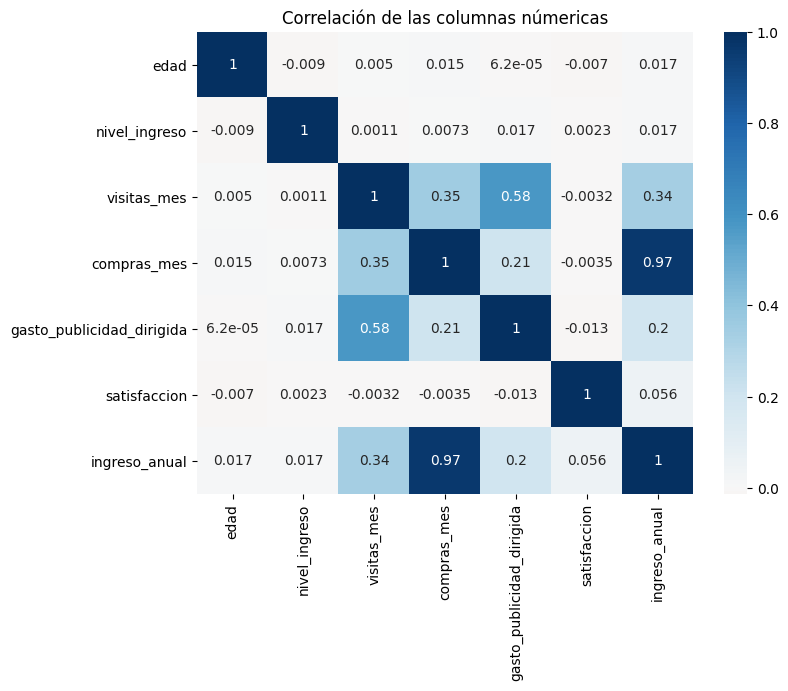

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
corr_num= columnas_numericas.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_num, annot= True, cmap="RdBu", center= 0)
plt.title("Correlación de las columnas númericas")
plt.show()

Observaciones generales (Heatmap)  
**- Sincronía en transacciones:** `compras_mes` e `ingreso_anual` se mueven de manera conjunta con una relación lineal casi perfecta **(0.97)**, lo que refleja una alta consistencia en el registro de la actividad comercial.

**- Coincidencia en tráfico y pauta:** Se identifica una tendencia positiva moderada-fuerte **(0.58)** entre `visitas_mes` y `gasto_publicidad_dirigida`, mostrando que los usuarios con más sesiones registradas coinciden con los de mayor asignación publicitaria.

**- Autonomía de variables demográficas y de percepción:** Las variables `edad`, `satisfaccion` y `nivel_ingreso` muestran coeficientes cercanos a cero frente al resto de las columnas, indicando que su comportamiento en la muestra es linealmente independiente de las métricas transaccionales.


Observaciones respecto a `ingreso_anual`  
**- Vínculo con la interacción en la plataforma:** Se observa una relación positiva moderada **(0.34)** entre `ingreso_anual` y `visitas_mes`, lo que indica que un mayor volumen de visitas tiende a alinearse con un mayor valor monetario del cliente para la empresa.

**- Independencia del perfil socioeconómico:** El `ingreso_anual` generado para la empresa no muestra relación lineal alguna **(0.017)** con el `nivel_ingreso` propio del cliente, señalando que la capacidad económica estimada del usuario y el gasto que realiza dentro de la plataforma varían de forma separada.

### Scatterplot general

In [11]:
print( "Conteo de miembros premium (0= No premium | 1= cliente premium):" )
print( df['miembro_premium'].value_counts() ) 
print( "\nConteo de ususarios activos (no abandono= 0) e inactivos (abandono = 1):")
print( df['abandono'].value_counts() )

Conteo de miembros premium (0= No premium | 1= cliente premium):
0    12911
1     2089
Name: miembro_premium, dtype: int64

Conteo de ususarios activos (no abandono= 0) e inactivos (abandono = 1):
0    12739
1     2261
Name: abandono, dtype: int64


# Justificación de pairplot general
Para validar visualmente la linealidad de los coeficientes de Pearson, se construyó una matriz de dispersión (pairplot) enfocada en las variables con mayor asociación (`ingreso_anual`, `compras_mes`, `visitas_mes` y `gasto_publicidad_dirigida`). El gráfico permitió confirmar que las tendencias ascendentes son consistentes y libres de relaciones complejas o outliers ocultos, ratificando además que la fuerte relación entre compras e ingresos ($0.97$) funciona como una **excelente línea base para el control operacional y la auditoría de datos del negocio.**

Aunque se evaluó incorporar una segmentación visual inmediata mediante variables como `miembro_premium` o `abandono`, se decidió mantener el enfoque general debido a un notable desbalance de clases, donde los segmentos minoritarios representan apenas el $14%$ y $15%$ de los $15,000$ registros, respectivamente. Introducir etiquetas de color (hue) en este punto habría provocado un efecto de ocultamiento (masking) por parte de la masa mayoritaria de usuarios; por lo tanto, el análisis detallado de estos grupos se desplaza justificadamente hacia la siguiente fase de segmentación del proyecto.

### Scatterplot para pares clave

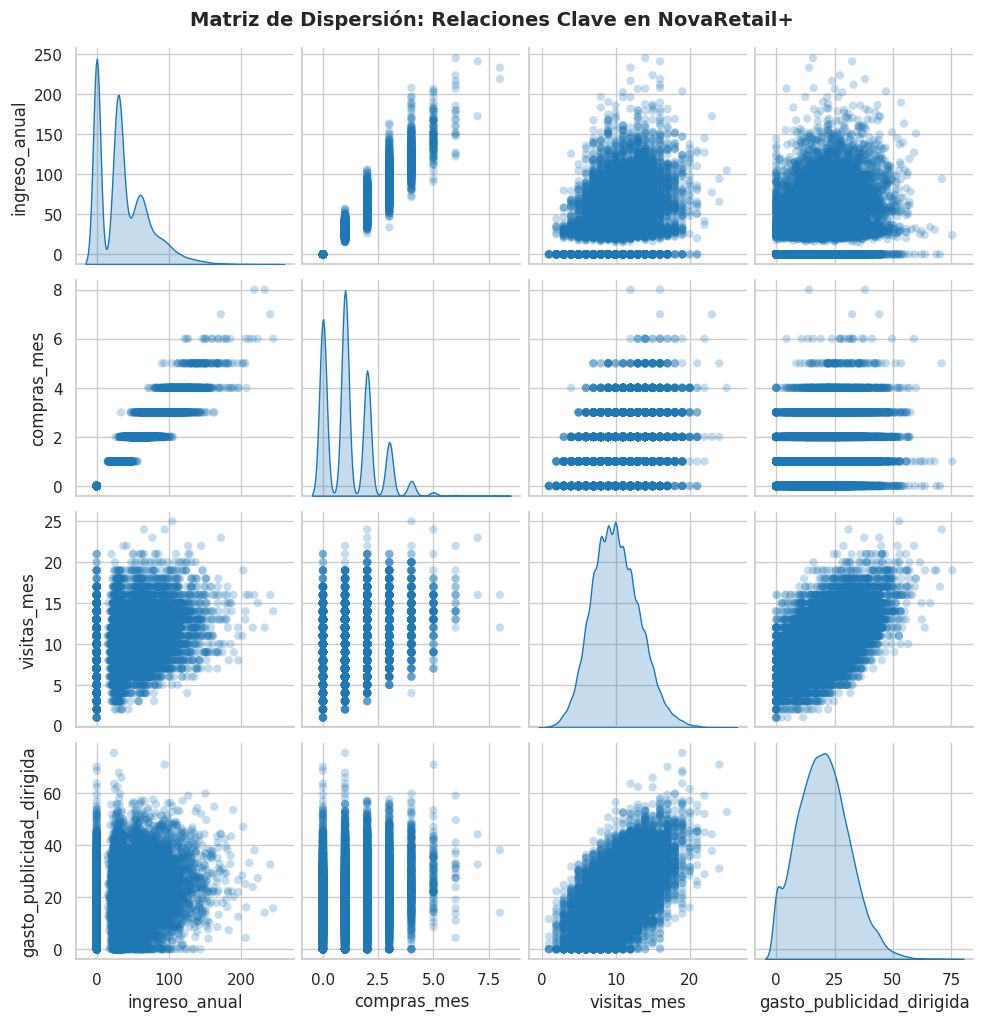

In [12]:
# Visualizar pares de variables con relaciones moderadas o fuertes
variables_clave = ["ingreso_anual", "compras_mes", "visitas_mes","gasto_publicidad_dirigida"]

# estilo visual
sns.set_theme(style="whitegrid")

# pairplot
g = sns.pairplot(
    data=df[variables_clave],  
    vars=variables_clave,
    kind="scatter",
    diag_kind="kde",  # Mostrar la distribución de las variables
    plot_kws={
        "alpha": 0.25,  
        "color": "#1f77b4",  
        "edgecolor": "none",  # Eliminación el borde de los puntos para que se aprecie mejor la densidad
    },
    diag_kws={"color": "#1f77b4", "fill": True},
)

# Ajustes estéticos generales
g.fig.suptitle(
    "Matriz de Dispersión: Relaciones Clave en NovaRetail+",
    y=1.02,
    fontsize=14,
    fontweight="bold",
)
plt.show()

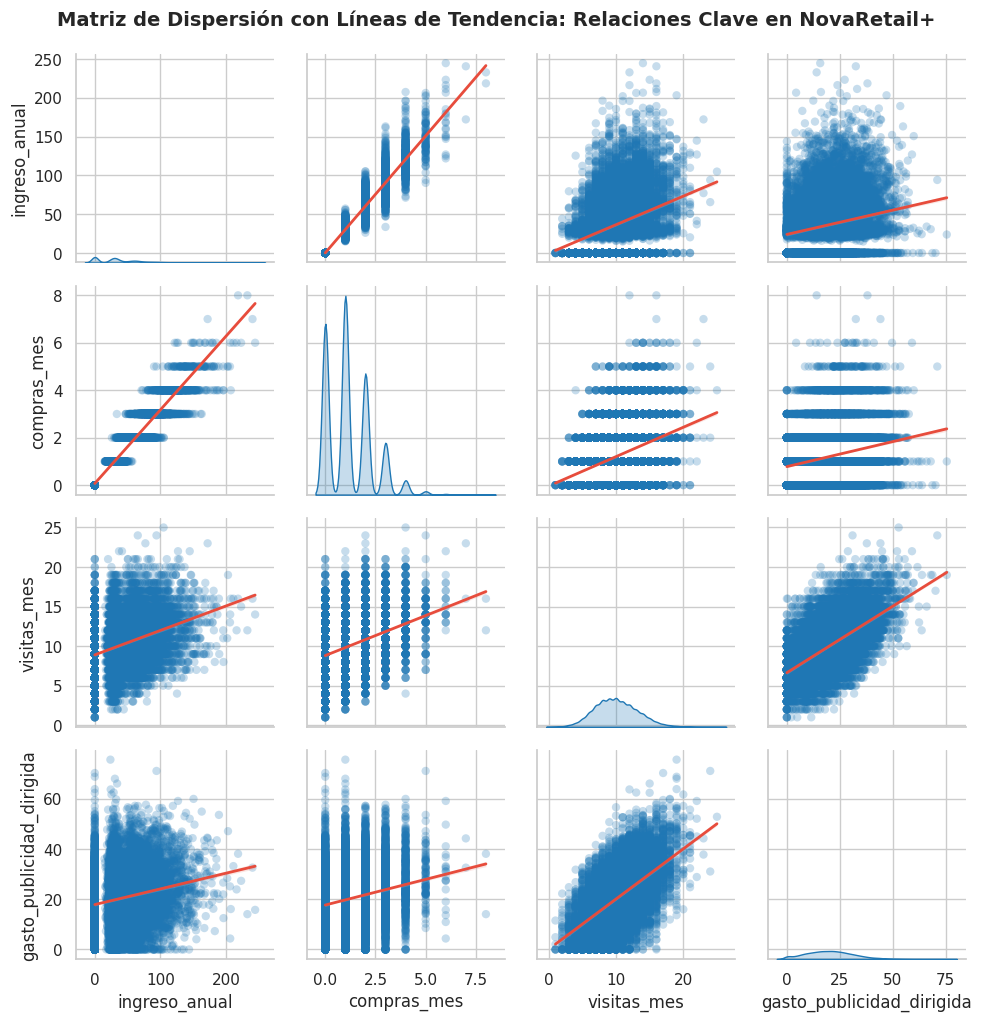

In [13]:
# Visualizar pares de variables con relaciones moderadas o fuertes
variables_clave = [
    "ingreso_anual",
    "compras_mes",
    "visitas_mes",
    "gasto_publicidad_dirigida",
]

# Estilo visual
sns.set_theme(style="whitegrid")

# PairGrid vacío definiendo las variables y la distribución en la diagonal
g = sns.PairGrid(data=df[variables_clave], vars=variables_clave)
g.map_diag(sns.kdeplot, color="#1f77b4", fill=True)

# 2. Forzamos a que todos los paneles fuera de la diagonal tengan el gráfico de regresión
g.map_offdiag(
    sns.regplot,
    scatter_kws={
        "alpha": 0.25,
        "color": "#1f77b4",
        "edgecolor": "none",
    },  # Configuración de los puntos
    line_kws={
        "color": "#e74c3c",
        "linewidth": 2,
    },  # Configuración de la línea de tendencia
)

# Ajustes estéticos generales
g.fig.suptitle(
    "Matriz de Dispersión con Líneas de Tendencia: Relaciones Clave en NovaRetail+",
    y=1.02,
    fontsize=14,
    fontweight="bold",
)
plt.show()

Observaciones iniciales (Scatterplot)

**Distribución de las Variables (Diagonal):** `visitas_mes` exhibe una distribución normal (campana simétrica); `gasto_publicidad_dirigida` presenta un sesgo positivo hacia montos bajos; mientras que `ingreso_anual` y `compras_mes` muestran un comportamiento multimodal, sugiriendo visualmente la presencia de distintos segmentos de usuarios.

**`ingreso_anual` vs. `compras_mes`**
- Relación positiva con dispersión muy baja. Los datos muestran un alineamiento ascendente estrecho y uniforme que evidencia una fuerte colinealidad, sin presencia de outliers. **Funciona como una línea base idónea para el control operativo.**

**`ingreso_anual` vs `visitas_mes`**
- Relación positiva con dispersión media-alta. La nube de puntos es amplia pero mantiene una inclinación ascendente sutil, mostrando que rangos altos de visitas tienden a coincidir con mayores ingresos, sin registrar anomalías visuales.

**`ingreso_anual` vs `gasto_publicidad_dirigida`**
- Relación positiva con dispersión alta. El patrón gráfico es difuso y extendido en la base, reflejando una tendencia lineal débil donde los datos se mantienen agrupados dentro del cuerpo general, libre de valores atípicos aislados.

## Sección 4 - Coeficientes de correlación y evidencia numérica

### Pearson / Spearman

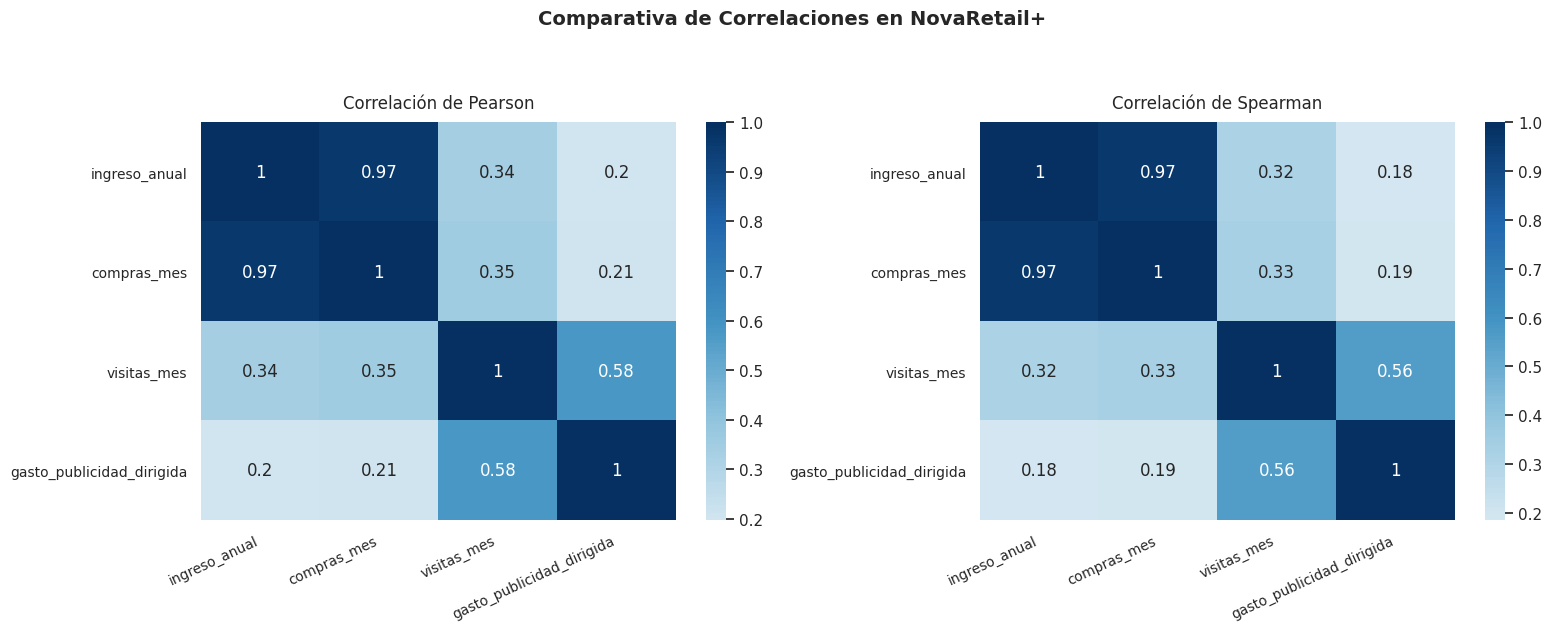

In [14]:
# Calcular correlación entre variables relevantes

# Matrices de correlación Pearson y Spearman
corr_pearson = df[variables_clave].corr(method="pearson")
corr_spearman = df[variables_clave].corr(method="spearman")

# Calcular correlación entre variables relevantes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Heatmap para corr_pearson
sns.heatmap(corr_pearson, annot= True, cmap="RdBu", center= 0, ax=axes[0])
axes[0].set_title("Correlación de Pearson", fontsize=12, pad=10)

# Ajustar etiquetas de Pearson para que no se amontonen
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha="right", fontsize=10)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=10)

# Heatmap para corr_spearman
sns.heatmap(corr_spearman, annot= True, cmap="RdBu", center= 0, ax=axes[1])
axes[1].set_title("Correlación de Spearman", fontsize=12, pad=10)

# Ajustar etiquetas de Spearman para que no se amontonen
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha="right", fontsize=10)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=10)

# Ajustes estéticos
fig.suptitle(
    "Comparativa de Correlaciones en NovaRetail+",
    fontsize=14,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
plt.show()

**Conclusión del Diagnóstico de Coeficientes (Pearson vs. Spearman):**

La comparación matemática entre ambas matrices revela una convergencia casi exacta en todos los pares de variables, registrando variaciones máximas marginales de apenas $\pm0.02$. Esta similitud paramétrica confirma de forma robusta dos supuestos clave:

- Las relaciones identificadas son estrictamente lineales y carecen de curvaturas monótonas complejas.
- El conjunto de datos se encuentra libre de valores atípicos **(outliers)** influyentes que alteren o distorsionen el cálculo del coeficiente de Pearson.

Por lo tanto, se justifica metodológicamente el uso exclusivo de la matriz de Pearson como base matemática para los modelos lineales subsecuentes de la fase analítica.

### Punto-biserial

In [15]:
# Calcular correlación entre variables relevantes
cols_num= ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
cols_cate= ['miembro_premium', 'abandono']

def calculo_biserialpoint (df, cols_cate, cols_num):
    result_biserialpoint= []     # Lista vacia para que se llene despues de los bucles for y utilizar .append()
    for col_c in cols_cate:
            for col_n in cols_num:
                coef, p_value= pointbiserialr(df[col_c], df[col_n])
                result_biserialpoint.append({      # .append() para agregar las columnas a result_biserialpoint
                'variable_categorica': col_c,
                'variable_numerica': col_n,
                'coeficiente': coef,
                'p-value': p_value
            })
    
    return pd.DataFrame(result_biserialpoint)   # regresa un data frame con los resultados de los cruces de biserialpoint

# Ejecutar la función y guardar el nuevo dataframe
df_result_bp= calculo_biserialpoint(df, cols_cate, cols_num)

In [16]:
df_result_bp.head(20)

,variable_categorica,variable_numerica,coeficiente,p-value
0,miembro_premium,edad,0.004605,5.727735e-01
1,miembro_premium,nivel_ingreso,-0.005598,4.929586e-01
2,miembro_premium,visitas_mes,-0.012657,1.211330e-01
3,miembro_premium,compras_mes,0.003431,6.743982e-01
4,miembro_premium,gasto_publicidad_dirigida,0.002721,7.389843e-01
5,miembro_premium,satisfaccion,0.025734,1.621474e-03
6,miembro_premium,ingreso_anual,0.093099,3.094308e-30
7,abandono,edad,-0.011500,1.590069e-01
8,abandono,nivel_ingreso,0.005870,4.722302e-01
9,abandono,visitas_mes,-0.008943,2.734362e-01


Observaciones Punto-biserial

**`miembro_premium` vs `ingreso_anual`**
- Se identificó una asociación positiva y estadísticamente significativa entre el estatus de **miembro_premium** y el **ingreso_anual** de los usuarios, aunque la magnitud de la fuerza de asociación es débil (coeficiente de correlación biserial puntual = $0.093$, $p\text{-value} = 3.09 \times 10^{-30}$). Esto indica que los usuarios premium tienden a registrar ingresos anuales ligeramente más altos en la muestra.

**`miembro_premium` vs `satisfacción`**
- Existe una relación positiva muy débil, pero estadísticamente significativa entre ser **miembro premium** y el nivel de **satisfacción** (coeficiente = $0.025$, $p\text{-value} = 1.62 \times 10^{-3}$). Los datos sugieren que la condición de cliente premium coocurre con mayores niveles de satisfacción, una asociación que cuenta con respaldo estadístico al encontrarse por debajo del umbral estándar de significancia ($p < 0.05$).
  

**`abandono` vs `satisfacción`**
- El análisis revela una asociación negativa muy débil y estadísticamente significativa entre el **abandono** y la **satisfacción** del usuario (coeficiente = $-0.0238$, $p\text{-value} = 3.51 \times 10^{-3}$). Este comportamiento indica que menores puntuaciones en la escala de satisfacción se asocian de forma medible con la presencia de abandono dentro de los registros analizados.

### V de Cramér

In [17]:

# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    result_cramerv= []
    
    tabla= pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    n= tabla.values.sum()
    v= np.sqrt(chi2/(n*(min(tabla.shape)-1)))

    result_cramerv.append({
        'variable_1': col1,
        'variable_2': col2,
        'Coef (Cramer V)': v,
        'p_value': p_value
                          })       
    return pd.DataFrame(result_cramerv)

In [18]:
# Aplicar V de Cramér en variables relevantes (guardar resultados)
cramer_v_result = cramer_v ( df, 'region', 'tipo_dispositivo' )

# Corroboración de resultados guardados en:
cramer_v_result.head()

,variable_1,variable_2,Coef (Cramer V),p_value
0,region,tipo_dispositivo,0.012378,0.596477


El análisis de asociación entre las variables categóricas `region` y `tipo_dispositivo` mediante el coeficiente **V de Cramer** arrojó un valor de $0.0124$, acompañado de un $p\text{-value}$ de $0.5965$.

Dado que el $p\text{-value}$ es significativamente superior al umbral estándar de significancia estadística ($\alpha = 0.05$), se concluye que no existe evidencia estadística para afirmar que hay una asociación entre la región geográfica del usuario y el tipo de dispositivo que utiliza.

Al identificarse un comportamiento de uso homogéneo e independiente de la ubicación geográfica, se vuelve indispensable mantener y optimizar de forma equitativa la compatibilidad y experiencia de usuario en todas las plataformas (móvil, escritorio y tablet), garantizando un diseño responsivo integral sin priorizar ninguna infraestructura en particular por región.

## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 — **`ingreso_anual`** e **`compras_mes`**

**Evidencia visual:**
![Heatmap de Correlaciones](imagenes/Comparacion_correlaciones_pearson_separman.png)
   
**Evidencia numérica:** 
Coeficiente de correlación lineal (Pearson:**0.97** | Spearman: **0.97**) alto y positivo.

**Interpretación:** Existe una correlación positiva y estadísticamente fuerte entre el volumen de `compras_mes` de un usuario y el `ingreso_anual` que este genera para la empresa. En los registros se observa que un mayor flujo de transacciones mensuales coocurre de forma sistemática con un incremento marcado en la facturación anual total atribuida a ese cliente.

**No podemos afirmar:** Que incentivar artificialmente un mayor número de transacciones sea la causa única del aumento en los ingresos anuales, ya que el valor de cada ticket individual o la adquisición de categorías de productos de alto margen podrían actuar como variables moderadoras.

**Implicación de negocio:** Este hallazgo es clave para identificar y monitorear el segmento de alto valor (High-Value Customers) de la empresa. Permite usar el volumen de compras mensuales como un indicador operativo en tiempo real para predecir el impacto financiero anual. Además, sirve como métrica de control interno: si el volumen de compras mensuales disminuye, el sistema puede activar alertas tempranas de riesgo de pérdida de ingresos, permitiendo al equipo de retención intervenir antes de que afecte el balance anual.

### Hallazgo 2 — **`ingreso_anual`** e **`visitas_mes`**

**Evidencia visual:**
![Gráficos de dispersión](imagenes/grafico_dispersion_variables_numericas.png)
   
**Evidencia numérica:** 
Coeficiente de correlación Pearson: **0.34** | Spearman: **0.32**

**Interpretación:** Los datos indican que existe una relación lineal positiva moderada entre la cantidad de visitas mensuales que realiza un usuario y el volumen total de ingresos anuales que este le genera a la empresa. Esto demuestra que la frecuencia con la que un cliente entra a interactuar o navegar en la plataforma ocurre de manera distribuida y homogénea, ligeramente asociada con el valor de facturación anual acumulado.

**No podemos afirmar:** Que lograr que un usuario visite más veces la aplicación deba traducirse directamente en una mayor generación de ingresos anuales, ni que los clientes de alto valor monetario estén obligados a registrar una mayor frecuencia de visitas a la plataforma.

**Implicación de negocio:** El tráfico constante y la retención visual (visitas) son activos saludables en toda la base de usuarios, pero visitas no equivalen automáticamente a mayor facturación. Para el equipo de Crecimiento, esto implica que las estrategias para elevar los ingresos anuales no deben centrarse únicamente en "hacer que entren más veces", sino en mejorar la conversión y el valor del ticket promedio cuando ya están dentro de la interfaz. Permite además optimizar los recursos publicitarios sin segmentar la experiencia de navegación general basada solo en el valor transaccional del cliente.

### Hallazgo 3 — **`visitas_mes`** e **`gasto_publicidad_dirigida`**

**Evidencia visual:**
![Gráficos de dispersión](imagenes/grafico_dispersion_variables_numericas.png)
   
**Evidencia numérica:** 
Coeficiente de correlación Pearson: **0.58** | Spearman: **0.56**

**Interpretación:** Se observa una asociación lineal positiva entre la frecuencia de visitas mensuales y la inversión asignada a la publicidad dirigida. Ambas métricas tienden a crecer y moverse de forma paralela a lo largo del comportamiento de los usuarios en el conjunto de datos.

**No podemos afirmar:** Que la inversión publicitaria sea la causa recíproca de que el usuario entre a la página, ya que un usuario que ya visita mucho la plataforma por iniciativa propia podría verse expuesto a más algoritmos publicitarios automatizados.

**Implicación de negocio:** Este hallazgo valida la eficiencia operativa y la sintonía de los canales de marketing. La correlación demuestra que la inversión publicitaria está alcanzando efectivamente las pantallas de los usuarios activos. Permite justificar la asignación de presupuestos hacia algoritmos de personalización (retargeting) para mantener a la comunidad enganchada con la marca.

### Hallazgo 4 — **`visitas_mes`** e **`compras_mes`**

**Evidencia visual:**
![Gráficos de dispersión](imagenes/grafico_dispersion_variables_numericas.png)
   
**Evidencia numérica:** 
Coeficiente de correlación Pearson: **0.35** | Spearman: **0.33**

**Interpretación:** Existe una relación lineal positiva entre la cantidad de visitas mensuales y el volumen de compras concretadas. En los registros analizados, una mayor actividad de navegación coocurre de manera sistemática con un número más alto de transacciones finalizadas.

**No podemos afirmar:** Que obligar a un usuario a navegar más tiempo (por ejemplo, ocultando botones o complicando el flujo) cause que compre más, ya que la intención de compra genuina suele impulsar ambas variables simultáneamente.

**Implicación de negocio:** Optimizar el embudo de conversión (Conversion Rate Optimization - CRO) es prioritario. Si las visitas y las compras caminan de la mano, cualquier mejora que facilite la transición desde la página de inicio hasta el carrito de compra (como procesos de checkout en un solo clic) maximizará el valor económico de cada visita registrada en NovaRetail.

### Hallazgo 5 — **`miembro_premium`** e **`ingreso_anual`**
   
**Evidencia numérica:** 
Coeficiente de correlación biserial puntual = $0.093$, $p\text{-value} = 3.09 \times 10^{-30}$.

**Interpretación:** Existe una asociación positiva y estadísticamente significativa entre el estatus de miembro premium y el ingreso anual de los usuarios. Al ser el p-valor sumamente cercano a cero, se confirma de manera categórica que el comportamiento no es producto del azar y que los usuarios con membresía premium tienden a registrar niveles de ingreso ligeramente más elevados en la muestra.

**No podemos afirmar:** Que el hecho de registrar un mayor ingreso anual cause directamente que un usuario adquiera la membresía premium, ni viceversa.

**Implicación de negocio:** El perfil con mayor poder adquisitivo muestra afinidad con el modelo de suscripción premium. Esto permite refinar las campañas de marketing enfocado (target) hacia sectores demográficos de ingresos medios-altos para optimizar la tasa de conversión de la membresía.

### Hallazgo 6 — **`miembro_premium`** y **`satisfaccion`**

**Evidencia numérica:** Coeficiente de correlación biserial puntual = $0.025$, $p\text{-value} = 1.62 \times 10^{-3}$.

**Interpretación:** Se detectó una relación positiva, con una magnitud muy débil pero estadísticamente significativa entre ambas variables. Dado que el p-valor es inferior al umbral estándar de significancia ($\alpha = 0.05$), los datos demuestran que pertenecer al grupo de miembros premium coocurre de forma medible con valoraciones de satisfacción más altas por parte del cliente. 

**No podemos afirmar:** Que otorgar una membresía premium sea la causa única del incremento en la satisfacción, o que un cliente satisfecho decida volverse premium por esa sola razón.

**Implicación de negocio:** El programa premium actual mantiene una percepción favorable asociada a una buena experiencia de usuario. Se deben auditar los beneficios específicos de este segmento para replicar los atributos de valor en otras áreas del servicio.

### Hallazgo 7 — **`abandono`** y **`satisfaccion`**

**Evidencia numérica:** Coeficiente de correlación biserial puntual = $-0.0238$, $p\text{-value} = 3.51 \times 10^{-3}$ (es decir, $0.00351$).

**Interpretación:** El análisis identificó una asociación muy débil, negativa y estadísticamente significativa entre el abandono (churn) y la satisfacción del usuario. Al ser el coeficiente negativo y el p-valor menor a $0.05$, se valida numéricamente que las puntuaciones más bajas en la escala de satisfacción se vinculan de manera directa con la presencia de abandono dentro de los registros.

**No podemos afirmar:** Que la insatisfacción sea el único detonante o la causa mecánica que obligue al usuario a abandonar la plataforma, ya que podrían intervenir factores externos no medidos en este modelo.

**Implicación de negocio:** La satisfacción percibida es un indicador temprano crítico para la retención. Es viable diseñar un sistema de alertas comerciales (Early Warning System) enfocado en usuarios con bajas calificaciones de satisfacción para abordarlos proactivamente antes de que ocurra el abandono.

### Hallazgo 8 — **`region`** y **`tipo_dispositivo`**

**Evidencia numérica:** Coeficiente V de Cramer = $0.0124$, $p\text{-value} = 0.5965$.

**Interpretación:** Dado que el p-value supera ampliamente el nivel de significancia estándar de $0.05$, no existe evidencia estadística para afirmar que el tipo de dispositivo que utiliza el usuario esté asociado con su ubicación geográfica. La distribución en el uso de móviles, escritorios y tablets se comporta de manera homogénea.

**No podemos afirmar:** Que la región determine el tipo de dispositivo de acceso, ni que el dispositivo defina la procedencia geográfica del usuario.

**Implicación de negocio:** No es necesario segmentar los esfuerzos de infraestructura técnica o servidores por región geográfica según el dispositivo. El equipo de ingeniería debe concentrar los recursos en un desarrollo responsivo unificado para optimizar la experiencia en todas las pantallas por igual a nivel nacional.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Los análisis estadísticos y coeficientes implementados en este estudio (Coeficiente Biserial Puntual, V de Cramer, Pearson y Spearman) están diseñados exclusivamente para identificar y cuantificar la fuerza y dirección de las relaciones entre variables. Por lo tanto, ninguno de los hallazgos debe interpretarse como una relación de causa y efecto. Por ejemplo, el hecho de que un mayor volumen de compras mensuales coocurra con un incremento en el ingreso_anual generado no significa que el número de transacciones sea la única causa de la facturación, ya que intervienen variables moderadoras como el valor del ticket promedio o el margen del producto.

- El conjunto de datos representa un corte temporal específico de los registros de la plataforma. Al no contar con una estructura longitudinal o de series de tiempo, el análisis se encuentra limitado para identificar patrones estacionales, ciclos de vida del cliente o tendencias macroeconómicas que afecten el comportamiento transaccional a lo largo de varios años.

- Las variables numéricas capturan la actividad actual (visitas_mes, compras_mes), pero el dataset no cuenta con variables cualitativas de contexto (como el tipo de soporte técnico recibido o encuestas abiertas de satisfacción) que permitan profundizar en las razones detrás de la pérdida de interés o el abandono.

### **Próximos pasos** 

**Monitoreo Transaccional y Control Interno (Prevención de Anomalías):**
- Aprovechando la fuerte correlación entre compras_mes e ingreso_anual (facturación generada), se recomienda utilizar el volumen de transacciones mensuales como un indicador operativo en tiempo real. Esto permitirá diseñar un sistema de monitoreo interno y prevención de fraudes: si un perfil de usuario experimenta picos de compra atípicos o caídas drásticas e inesperadas en su comportamiento transaccional regular, el sistema podrá disparar alertas automáticas para auditoría o campañas de retención proactivas.

**Optimización del Embudo de Conversión:**
- Dado que las visitas mensuales y el volumen de compras presentan una asociación lineal positiva significativa, el esfuerzo del equipo de Producto no debe centrarse únicamente en incrementar el tráfico, sino en mejorar la conversión dentro de la interfaz. Se sugiere implementar mejoras de UX/UI (como procesos de pago o checkout en un solo clic) para capitalizar económicamente cada visita registrada.

**Garantía de Infraestructura Digital Responsiva Unificada:**
- La independencia estadística demostrada entre la localización geográfica del usuario y el tipo de dispositivo de acceso descarta la necesidad de crear infraestructuras técnicas o servidores segmentados por región. Se debe priorizar un diseño responsivo global que mantenga una experiencia de navegación idéntica y equitativa en entornos móviles, de escritorio y tablets.

**Evolución Longitudinal:**
- Como propuesta clave para superar la restricción del enfoque transversal actual, se plantea la transición hacia un análisis longitudinal mediante el desarrollo de un Análisis de Cohortes y Series de Tiempo utilizando una ventana de datos históricos de al menos tres años. Esta necesidad metodológica se fundamenta en que, al verificar que la columna de ID cuenta con 15,000 valores únicos para un total exacto de 15,000 registros, queda en evidencia que el conjunto de datos actual captura únicamente la actividad de un solo mes de análisis (una "foto fija"). Implementar esta evolución permitirá segmentar a los usuarios según su periodo de adquisición para evaluar la madurez y el valor del cliente a largo plazo, determinando si los usuarios antiguos registran mayor volumen de compras e ingreso_anual en temporadas clave como el invierno en comparación con los nuevos ingresos. Asimismo, facilitará medir la resiliencia de la plataforma ante factores externos (como crisis económicas o campañas virales) y validará si los patrones de navegación (visitas_mes) y conversión (compras_mes) permanecen estables año tras año o si el ciclo de vida del cliente sufre modificaciones estructurales con el tiempo.